# Exploratory Data Analysis 

In [3]:
import os
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos los datos ya curados desde drug_db.py
from drug_db import df_DrugBank_clean, cyp_counter

print(f"Datos cargados desde drug_db.py")
print(f"   - Moléculas totales: {len(df_DrugBank_clean)}")
print(f"   - CYPs distintos en toda la base: {len(cyp_counter)}")

Datos cargados desde drug_db.py
   - Moléculas totales: 1368
   - CYPs distintos en toda la base: 33


In [4]:
THRESHOLD = 50 

# CYPs que están por debajo del umbral
uncommon_cyps = [k for k, v in cyp_counter.items() if v < THRESHOLD]

# Contador solo con los CYPs que superan el umbral (para gráficas)
cyp_counter_filtered = Counter({k: v for k, v in cyp_counter.items() if v >= THRESHOLD})

# Aplicamos el filtro al DataFrame
df_all = df_DrugBank_clean.copy()
df_all["CYPs_filtered"] = df_all["CYPs"].apply(
    lambda cyps: [c for c in cyps if c not in uncommon_cyps]
)

# DataFrame que usaremos para modelado: solo moléculas con al menos un CYP tras filtrar
df_filtered = df_all[df_all["CYPs_filtered"].map(len) > 0].copy()

print(f"Umbral seleccionado: {THRESHOLD}")
print(f"   - CYPs totales: {len(cyp_counter)}")
print(f"   - CYPs que superan el umbral: {len(cyp_counter_filtered)}")
print(f"   - Moléculas con al menos un CYP tras filtrar: {len(df_filtered)}")

Umbral seleccionado: 50
   - CYPs totales: 33
   - CYPs que superan el umbral: 13
   - Moléculas con al menos un CYP tras filtrar: 1354


### CYP Frequency Analysis

We use `cyp_counter` from *drug_db.py* to get the 13 most common CYPs (those with more than 50 compounds).  
These are converted into a DataFrame with columns:

- **CYP** → enzyme name  
- **DrugCount** → number of drugs metabolized  

Finally, `describe()` summarizes the distribution of drug counts among these CYPs.


In [5]:
# Creamos una tabla con todos los CYPs, ordenados de mayor a menor frecuencia
df_freq_all = pd.DataFrame(
    [(cyp, count) for cyp, count in cyp_counter.items()],
    columns=["CYP", "DrugCount"]
)
df_freq_all["Percentage"] = (df_freq_all["DrugCount"] / len(df_all)) * 100
df_freq_all = df_freq_all.sort_values("DrugCount", ascending=False).reset_index(drop=True)

# Mostramos los 10 primeros y los que superan el umbral
print("Distribución de CYPs (primeros 10):")
display(df_freq_all.head(10))

print(f"\nCYPs con frecuencia >= {THRESHOLD}:")
display(df_freq_all[df_freq_all["DrugCount"] >= THRESHOLD])

Distribución de CYPs (primeros 10):


,CYP,DrugCount,Percentage
0,CYP3A4,1051,76.827485
1,CYP2D6,417,30.482456
2,CYP2C9,415,30.336257
3,CYP1A2,339,24.780702
4,CYP3A5,337,24.634503
5,CYP2C19,335,24.488304
6,CYP2C8,318,23.245614
7,CYP2B6,223,16.301170
8,CYP3A7,179,13.084795
9,CYP2E1,140,10.233918



CYPs con frecuencia >= 50:


,CYP,DrugCount,Percentage
0,CYP3A4,1051,76.827485
1,CYP2D6,417,30.482456
2,CYP2C9,415,30.336257
3,CYP1A2,339,24.780702
4,CYP3A5,337,24.634503
5,CYP2C19,335,24.488304
6,CYP2C8,318,23.245614
7,CYP2B6,223,16.301170
8,CYP3A7,179,13.084795
9,CYP2E1,140,10.233918


Gráfico de barras lineal (solo CYPs filtrados)

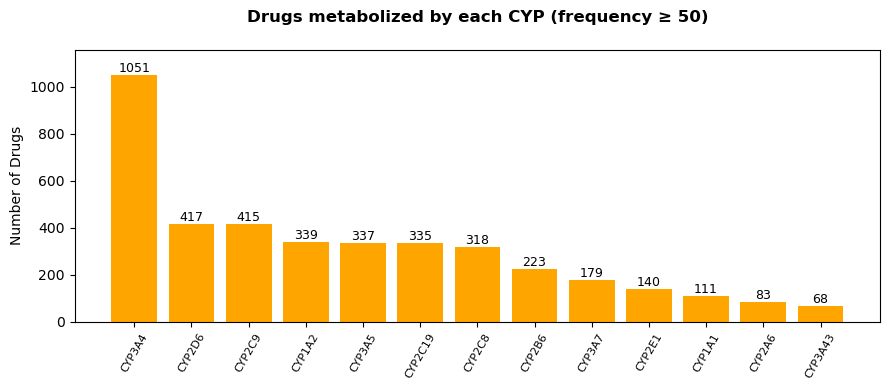

In [10]:
# Sort in descending order
sorted_items = sorted(cyp_counter_filtered.items(), key=lambda x: x[1], reverse=True)
names, values = zip(*sorted_items)

plt.figure(figsize=(9, 4))
bars = plt.bar(names, values, color="orange")

# Bar labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom', fontsize=9)

plt.ylabel("Number of Drugs", fontsize=10)
plt.xticks(rotation=60, ha="center", fontsize=8)
plt.title(f"Drugs metabolized by each CYP (frequency ≥ {THRESHOLD})", pad=20, fontweight="bold")
plt.tight_layout()
plt.ylim(0, max(values) * 1.1)
plt.show()

 Gráfico de barras en escala logarítmica (todos los CYPs, coloreando los raros)

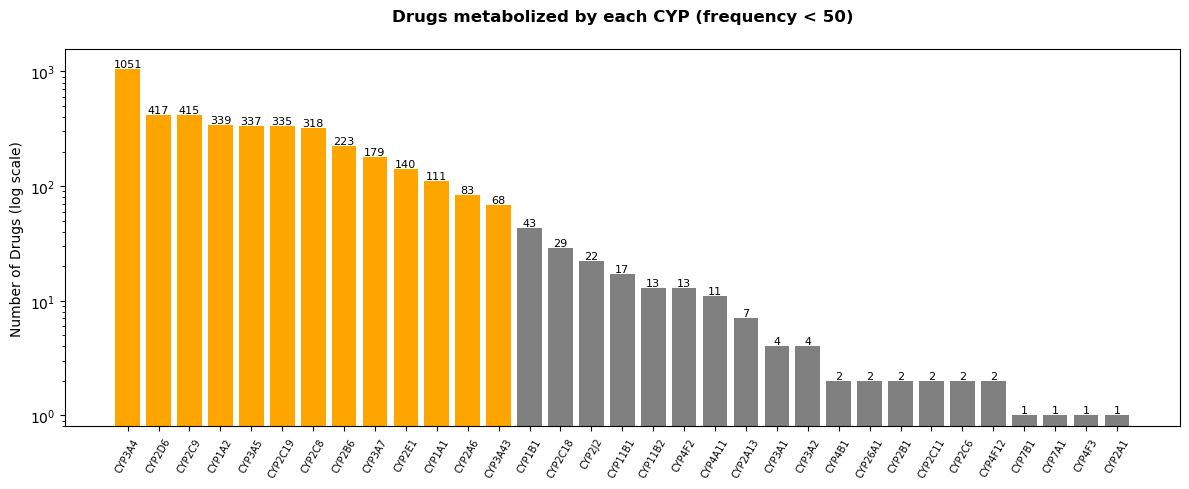

In [15]:
# Ensure sorted DataFrame for plotting
df_freq_all_sorted = df_freq_all.sort_values("DrugCount", ascending=False)

all_cyps = df_freq_all_sorted["CYP"].values
all_counts = df_freq_all_sorted["DrugCount"].values
colours = ["orange" if c >= THRESHOLD else "gray" for c in all_counts]

plt.figure(figsize=(12, 5))
bars = plt.bar(all_cyps, all_counts, color=colours)

# Etiquetas de valor solo para los que tienen count > 0
for bar, count in zip(bars, all_counts):
    if count > 0:
        plt.text(bar.get_x() + bar.get_width()/2, count,
                 str(count), ha='center', va='bottom', fontsize=8)

plt.yscale('log')
plt.ylabel("Number of Drugs (log scale)", fontsize=10)
plt.xticks(rotation=60, ha="center", fontsize=7)
plt.title(f"Drugs metabolized by each CYP (frequency < {THRESHOLD})", pad=20, fontweight="bold")
plt.ylim(0.8, max(all_counts) * 1.5)
plt.tight_layout()
plt.show()

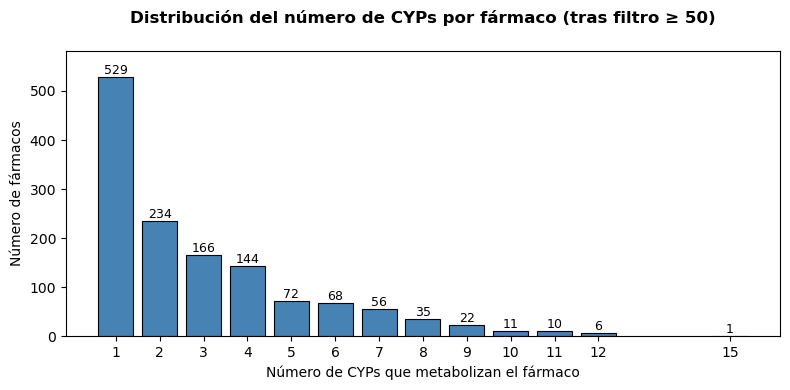

Resumen del número de CYPs por fármaco:
count    1354.000000
mean        2.966027
std         2.395555
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        15.000000
Name: CYPs_filtered, dtype: float64
   - Fármacos con 1 CYP: 529
   - Fármacos con >=2 CYPs: 825


In [21]:
# CYP count per drug
num_cyps = df_filtered["CYPs_filtered"].apply(len)

# Calcular frecuencias absolutas (cuántos fármacos tienen 1, 2, 3... CYPs)
counts = num_cyps.value_counts().sort_index()

plt.figure(figsize=(8, 4))
bars = plt.bar(counts.index, counts.values, color="steelblue", edgecolor="black", linewidth=0.8)

# Bar labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             int(height), ha='center', va='bottom', fontsize=9)

plt.xlabel("Número de CYPs que metabolizan el fármaco")
plt.ylabel("Número de fármacos")
plt.ylim(0, max(counts.values) * 1.1)
plt.title(f"Distribución del número de CYPs por fármaco (tras filtro ≥ {THRESHOLD})", pad=20, fontweight="bold")
plt.xticks(counts.index)  # Aseguramos que solo aparezcan los valores enteros presentes
plt.tight_layout()
plt.show()

# Stats
print("Resumen del número de CYPs por fármaco:")
print(num_cyps.describe())
print(f"   - Fármacos con 1 CYP: {sum(num_cyps == 1)}")
print(f"   - Fármacos con >=2 CYPs: {sum(num_cyps >= 2)}")

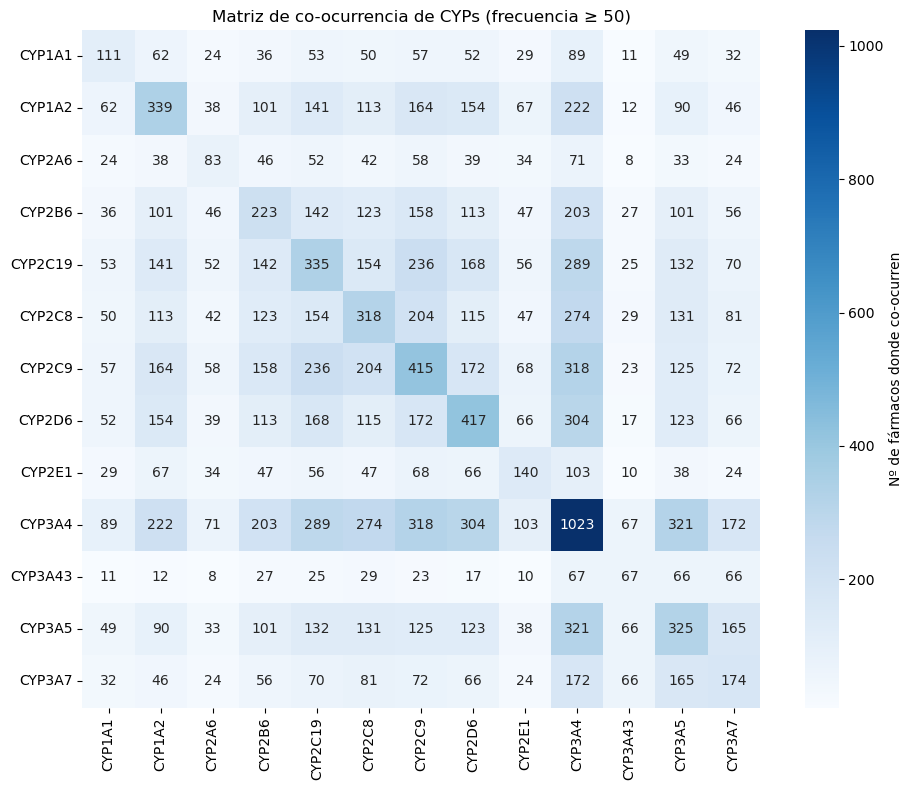

In [22]:
# Solo CYPs que superan el umbral
cyps_list = sorted(cyp_counter_filtered.keys())
n_cyps = len(cyps_list)

# Inicializar matriz de ceros
co_occ = np.zeros((n_cyps, n_cyps), dtype=int)

# Rellenar contando pares
for cyps in df_filtered["CYPs_filtered"]:
    cyps_set = set(cyps)
    for i, c1 in enumerate(cyps_list):
        if c1 in cyps_set:
            for j, c2 in enumerate(cyps_list):
                if c2 in cyps_set:
                    co_occ[i, j] += 1

# Convertir a DataFrame para el heatmap
df_co_occ = pd.DataFrame(co_occ, index=cyps_list, columns=cyps_list)

# Dibujar
plt.figure(figsize=(10, 8))
sns.heatmap(df_co_occ, annot=True, fmt='d', cmap='Blues', square=True,
            cbar_kws={'label': 'Nº de fármacos donde co-ocurren'})
plt.title(f"Matriz de co-ocurrencia de CYPs (frecuencia ≥ {THRESHOLD})")
plt.tight_layout()
plt.show()

In [24]:
# Moléculas que pierden TODAS sus anotaciones
lost_molecules = df_all[df_all["CYPs_filtered"].map(len) == 0]
num_lost = len(lost_molecules)
total = len(df_all)
pct_lost = (num_lost / total) * 100

print(f"Moléculas totales: {total}")
print(f"Moléculas que pierden todas sus anotaciones CYP al aplicar threshold={THRESHOLD}: {num_lost} ({pct_lost:.2f}%)")

if num_lost > 0:
    print("\n Ejemplos de moléculas afectadas (primeras 5):")
    display(lost_molecules[["DrugBank ID", "Name", "CYPs"]].head())

Moléculas totales: 1368
Moléculas que pierden todas sus anotaciones CYP al aplicar threshold=50: 14 (1.02%)

 Ejemplos de moléculas afectadas (primeras 5):


,DrugBank ID,Name,CYPs
2,DB00121,Biotin,[CYP1B1]
4,DB00152,Thiamine,[CYP4B1]
5,DB00162,Vitamin A,[CYP26A1]
74,DB00292,Etomidate,"[CYP11B1, CYP11B2]"
432,DB01022,Phylloquinone,[CYP4F2]


In [27]:
# Buscar por nombre (búsqueda parcial, sin distinción de mayúsculas)
targets = ["Ibuprofen", "Warfarin"]
for name in targets:
    match = df_all[df_all["Name"].str.contains(name, case=False, na=False)]
    if not match.empty:
        row = match.iloc[0]
        smiles = row["SMILES"]
        has_stereo = any(ch in smiles for ch in ['@', '/', '\\'])
        print(f"\n{name}:")
        print(f"   ID: {row['DrugBank ID']}")
        print(f"   SMILES: {smiles}")
        print(f"   Contiene estereoquímica? {'SÍ' if has_stereo else 'NO'}")

    else:
        print(f"\n{name}: No se encontró en el dataset.")


Ibuprofen:
   ID: DB01050
   SMILES: CC(C)CC1=CC=C(C=C1)C(C)C(O)=O
   Contiene estereoquímica? NO

Warfarin:
   ID: DB00682
   SMILES: CC(=O)CC(C1=CC=CC=C1)C1=C(O)C2=C(OC1=O)C=CC=C2
   Contiene estereoquímica? NO


In [41]:
stereo_chars = ['@', '/', '\\']

def has_stereo(smiles):
    return any(ch in smiles for ch in stereo_chars)

df_all["has_stereo"] = df_all["SMILES"].apply(has_stereo)
num_stereo = df_all["has_stereo"].sum()
total = len(df_all)

print(f"\n Total de moléculas: {total}")
print(f" Moléculas con SMILES que contienen estereoquímica: {num_stereo} ({num_stereo/total*100:.2f}%)")
print(f" Moléculas sin estereoquímica aparente: {total - num_stereo} ({(total-num_stereo)/total*100:.2f}%)")


 Total de moléculas: 1368
 Moléculas con SMILES que contienen estereoquímica: 689 (50.37%)
 Moléculas sin estereoquímica aparente: 679 (49.63%)
